In [1]:
import torch

In [2]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import random
from dreal import *
import matplotlib.patches as patches
from matplotlib import cm

In [3]:

torch.cuda.empty_cache()
torch.manual_seed(17)
random.seed()


In [4]:

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Pre-allocate numerical_x
numerical_x = torch.Tensor(500, 2).uniform_(-6, 6).float().to(device)


Using device: cpu


In [5]:

# Physical constants for inverted pendulum
MASS = 0.15
GRAVITY = 9.81
LENGTH = 0.5
FRICTION = 0.1
ML2 = MASS * (LENGTH ** 2)


In [6]:

def f(x):
    """Vectorized inverted pendulum dynamics f(x) - handles batched input"""
    if x.dim() == 1:
        x = x.unsqueeze(0)
    
    val = torch.stack([
        x[:, 1],
        (MASS * GRAVITY * LENGTH * torch.sin(x[:, 0]) - FRICTION * x[:, 1]) / ML2
    ], dim=1)
    
    return val.squeeze(0) if val.shape[0] == 1 else val

def g(x):
    """Vectorized g(x) - handles batched input"""
    if x.dim() == 1:
        x = x.unsqueeze(0)
    
    val = torch.stack([
        torch.zeros_like(x[:, 0]),
        torch.full_like(x[:, 0], 1.0 / ML2)
    ], dim=1)
    
    return val.squeeze(0) if val.shape[0] == 1 else val

def div_f(x):
    """Vectorized divergence of f - handles batched input"""
    divergence = -FRICTION / ML2
    if x.dim() == 1:
        return torch.tensor(divergence, device=device)
    else:
        return torch.full((x.shape[0],), divergence, device=device)

def div_g(x):
    """Vectorized divergence of g"""
    if x.dim() == 1:
        return torch.tensor(0.0, device=device)
    else:
        return torch.zeros(x.shape[0], device=device)

In [7]:

class polynomial_net(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(polynomial_net, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim)
        )
        self._initialize_weights()

    def _initialize_weights(self):
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        return self.net(x)

class polynomial_net_bias_Zero(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(polynomial_net_bias_Zero, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim)
        )
        self._initialize_weights()

    def _initialize_weights(self):
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)
                layer.bias.requires_grad = False
                

    def forward(self, x):
        return self.net(x)
                

class numerator_polynomial_net(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(numerator_polynomial_net, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Sigmoid(),
            nn.Linear(hidden_dim, output_dim),
            nn.Sigmoid()
        )
        self._initialize_weights()

    def _initialize_weights(self):
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        return self.net(x)

class GammaFunctionNet(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(GammaFunctionNet, self).__init__()
        self.linear_layer = nn.Linear(input_dim, output_dim)
        nn.init.constant_(self.linear_layer.weight, 0)
        nn.init.constant_(self.linear_layer.bias, 0)
        self.linear_layer.weight.requires_grad = False

    def forward(self, x):
        if x.dim() == 1:
            return abs(self.linear_layer.bias)
        return abs(self.linear_layer.bias.expand(x.shape[0], -1))

In [8]:

def gradient_batch(func, x):
    """Compute gradients for a batch of inputs efficiently"""
    x = x.clone().detach().requires_grad_(True)
    output = func(x).sum()
    grad = torch.autograd.grad(outputs=output, inputs=x, create_graph=True)[0]
    return grad

def gradient_batch_special_b(func, x):
    """Compute gradients of ||f(x)||^2 for a batch efficiently"""
    x = x.clone().detach().requires_grad_(True)
    output = func(x)
    output_norm_squared = (output ** 2).sum(dim=1).sum()
    grad = torch.autograd.grad(outputs=output_norm_squared, inputs=x, create_graph=True)[0]
    return grad

# ==================== FULLY VECTORIZED CONTROL DENSITY ====================

def control_density_risk_vectorized(x, f_fun, g_fun, a_fun, b_fun, c_fun):
    """FULLY VECTORIZED - processes entire batch at once"""
    batch_size = x.shape[0]
    
    # Compute all values in batch
    divergence_at_f = div_f(x)  # [batch_size]
    divergence_at_g = div_g(x)  # [batch_size]
    
    # Compute gradients for entire batch
    grad_at_a = gradient_batch(a_fun, x)  # [batch_size, 2]
    grad_at_c = gradient_batch(c_fun, x)  # [batch_size, 2]
    grad_at_b = gradient_batch_special_b(b_fun, x)  # [batch_size, 2]
    
    # Compute function values
    a_vals = a_fun(x).squeeze()  # [batch_size]
    c_vals = c_fun(x).squeeze()  # [batch_size]
    f_vals = f(x)  # [batch_size, 2]
    g_vals = g(x)  # [batch_size, 2]
    
    # Vectorized computation of term1
    term1 = (a_vals * divergence_at_f + 
             divergence_at_g * c_vals + 
             (grad_at_a * f_vals).sum(dim=1) + 
             (grad_at_c * g_vals).sum(dim=1))
    
    # Vectorized computation of term2
    scaled_x = 2 * x + grad_at_b  # [batch_size, 2]
    combined = f_vals * a_vals.unsqueeze(1) + g_vals * c_vals.unsqueeze(1)  # [batch_size, 2]
    term2 = (scaled_x * combined).sum(dim=1)
    
    return term1 - term2

def control_density_loss(x, f_fun, g_fun, a_fun, b_fun, c_fun, gamma_fun):
    """Optimized loss computation"""
    divergence = control_density_risk_vectorized(x, f_fun, g_fun, a_fun, b_fun, c_fun)
    gamma_vals = gamma_fun(x).squeeze()
    
    loss = F.relu(gamma_vals - divergence).mean()
    a_loss = F.relu( - a_fun(x)).mean()
    gamma_loss = F.relu(-gamma_vals).mean()
    
    return loss + a_loss + gamma_loss

In [9]:

def checkSMTconstraints(vars, a_learnt, divergence_learnt, ball_lb, ball_ub, config, epsilon=0):
    """Check the SMT constraints for the given variables and learnt parameters"""
    ball = Expression(0)
    
    for i in range(len(vars)):
        ball += vars[i]**2
    ball_in_bound = logical_and(ball >= ball_lb, ball <= ball_ub)
    
    a_condition = a_learnt >= 0
    divergence_condition = divergence_learnt > 0
    stability_condition = logical_and(
        logical_imply(ball_in_bound, divergence_condition),
        logical_imply(ball_in_bound, a_condition)
    )
    
    return CheckSatisfiability(logical_not(stability_condition), config)

def AddCounterexamples(x, CE, N, device):
    """Adds counterexamples to the sample set efficiently"""
    nearby = []
    for i in range(CE.size()):
        lb = CE[i].lb()
        ub = CE[i].ub()
        nearby_ = np.random.uniform(lb, ub, N)
        nearby.append(nearby_)
    
    # Vectorized counterexample addition
    new_points = np.column_stack(nearby)
    new_points_tensor = torch.tensor(new_points, dtype=torch.float32, device=device)
    x = torch.cat((x, new_points_tensor), dim=0)
    x = torch.unique(x, dim=0)
    
    return x, new_points_tensor

# ==================== SYMBOLIC NN CLASSES ====================

class SymbolicNN:
    """Convert neural networks to symbolic expressions for dReal"""
    def __init__(self, net):
        self.weights = []
        self.biases = []
        self.extract_params(net)

    def extract_params(self, net):
        for layer in net.net:
            if isinstance(layer, nn.Linear):
                self.weights.append(layer.weight.detach().cpu().numpy())
                if layer.bias is not None:
                    self.biases.append(layer.bias.detach().cpu().numpy())

    def forward_symbolic(self, vars):
        z = vars
        for i in range(len(self.weights) - 1):
            z = self._linear_symbolic(z, self.weights[i], self.biases[i])
            z = [tanh(zi) for zi in z]
        z = self._linear_symbolic(z, self.weights[-1], self.biases[-1])
        return z

    def _linear_symbolic(self, x, weight, bias):
        out = []
        for i in range(weight.shape[0]):
            expr = bias[i]
            for j in range(weight.shape[1]):
                expr += weight[i,j] * x[j]
            out.append(expr)
        return out

class activSymbolicNN:
    """Convert neural networks with sigmoid to symbolic expressions"""
    def __init__(self, net):
        self.weights = []
        self.biases = []
        self.extract_params(net)

    def extract_params(self, net):
        for layer in net.net:
            if isinstance(layer, nn.Linear):
                self.weights.append(layer.weight.detach().cpu().numpy())
                if layer.bias is not None:
                    self.biases.append(layer.bias.detach().cpu().numpy())

    def forward_symbolic(self, vars):
        z = vars
        for i in range(len(self.weights)):
            z = self._linear_symbolic(z, self.weights[i], self.biases[i])
            z = [(1/(1 + exp(-zi))) for zi in z]
        return z

    def _linear_symbolic(self, x, weight, bias):
        out = []
        for i in range(weight.shape[0]):
            expr = bias[i]
            for j in range(weight.shape[1]):
                expr += weight[i,j] * x[j]
            out.append(expr)
        return out

def candidate_constraint_learnt(vars, a_fun, b_fun, c_fun):
    """Construct candidate constraints for the learnt functions"""
    a_sym = activSymbolicNN(a_fun).forward_symbolic(vars)[0]
    b_sym = SymbolicNN(b_fun).forward_symbolic(vars)
    c_sym = SymbolicNN(c_fun).forward_symbolic(vars)[0]
    
    b_sym = sum([bi**2 for bi in b_sym])
    
    # Symbolic dynamics for inverted pendulum
    f_val = [
        vars[1],
        (MASS * GRAVITY * LENGTH * sin(vars[0]) - FRICTION * vars[1]) / ML2
    ]
    g_val = [
        0.0 * vars[0],
        1.0 / ML2
    ]
    
    f_div = -FRICTION / ML2
    g_div = 0
    
    grad_a = [a_sym.Differentiate(vars[i]) for i in range(len(vars))]
    grad_c = [c_sym.Differentiate(vars[i]) for i in range(len(vars))]
    grad_b = [b_sym.Differentiate(vars[i]) for i in range(len(vars))]
    
    constraint1 = (a_sym * f_div + g_div * c_sym + 
                   sum([grad_a[i] * f_val[i] for i in range(len(f_val))]) + 
                   sum([grad_c[i] * g_val[i] for i in range(len(g_val))]))
    
    scaled_vars = [2 * var_i for var_i in vars]
    constraint2 = [scaled_vars[i] + grad_b[i] for i in range(len(vars))]
    constraint2 = sum([constraint2[i] * (f_val[i] * a_sym + g_val[i] * c_sym) 
                      for i in range(len(f_val))])
    
    constraint = constraint1 - constraint2
    return a_sym, constraint


In [11]:
INPUT_DIM = 2
HIDDEN_DIM_A = 3
HIDDEN_DIM_B = 3
HIDDEN_DIM_C = 12
OUTPUT_DIM_B = 2

# LOAD THE MODELS
a_net = numerator_polynomial_net(INPUT_DIM, HIDDEN_DIM_A, 1).to(device)
a_net.load_state_dict(torch.load('Models/inverted_pendulum_a_net.pth', map_location=device))
b_net = polynomial_net_bias_Zero(INPUT_DIM, HIDDEN_DIM_B, OUTPUT_DIM_B).to(device)
b_net.load_state_dict(torch.load('Models/inverted_pendulum_b_net.pth', map_location=device))
c_net = polynomial_net(INPUT_DIM, HIDDEN_DIM_C, 1).to(device)
c_net.load_state_dict(torch.load('Models/inverted_pendulum_c_net.pth', map_location=device))

a_net1 = numerator_polynomial_net(INPUT_DIM, HIDDEN_DIM_A, 1).to(device)
a_net1.load_state_dict(torch.load('Models/inverted_pendulum_a_net1.pth', map_location=device))
b_net1 = polynomial_net_bias_Zero(INPUT_DIM, HIDDEN_DIM_B, OUTPUT_DIM_B).to(device)
b_net1.load_state_dict(torch.load('Models/inverted_pendulum_b_net1.pth', map_location=device))
c_net1 = polynomial_net(INPUT_DIM, HIDDEN_DIM_C, 1).to(device)
c_net1.load_state_dict(torch.load('Models/inverted_pendulum_c_net1.pth', map_location=device))

print("Models loaded successfully.")
a_net.eval()
b_net.eval()
c_net.eval()
a_net1.eval()
b_net1.eval()
c_net1.eval()

Models loaded successfully.


/tmp/ipykernel_767034/4004179128.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  a_net.load_state_dict(torch.load('Models/inverted_pendulum_a_net.pth', map_location=devi

polynomial_net(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=12, bias=True)
    (1): Tanh()
    (2): Linear(in_features=12, out_features=1, bias=True)
  )
)

In [12]:
def plot_density_countours(a_nn, b_nn, c_nn,density_threshold, device, plot_flow=True):
    # create meshgrid
    x1 = torch.linspace(-6, 6, 100)
    x2 = torch.linspace(-6, 6, 100)
    X, Y = np.meshgrid(x1,x2)

    # Convert to torch tensor
    grid_points = torch.tensor(np.column_stack([X.ravel(), Y.ravel()]), dtype=torch.float32).to(device)

    # compute the modified density function
    with torch.no_grad():
        rho_set = a_nn(grid_points) / (torch.exp( torch.sum(grid_points**2, dim=1, keepdim=True) + torch.sum((b_nn(grid_points))**2, dim=1, keepdim=True)))
        rho_set = rho_set.squeeze()
        rho_set = rho_set.cpu().numpy().reshape(X.shape)
    # plot the density function
    fig, ax = plt.subplots(figsize=(8, 6))
    # contours = ax.contour(X, Y, rho_set, levels=10, colors='k')

    ax.contour(X,Y,rho_set-density_threshold,levels=0,colors='black', linewidths=2,linestyles='solid', label='Mixed Density')

    filled_contours = ax.contourf(X, Y, rho_set, levels=10, alpha=0.3, cmap=cm.coolwarm)
    plt.colorbar(filled_contours, label='Density Value')

    if plot_flow:
        # create coarser grid for flow field
        x1_flow = np.linspace(-6, 6, 20)
        x2_flow = np.linspace(-6, 6, 20)
        X_flow, Y_flow = np.meshgrid(x1_flow, x2_flow)
        flow_points = torch.tensor(np.column_stack([X_flow.ravel(), Y_flow.ravel()]), dtype=torch.float32).to(device)

        # evaluate control policy u
        with torch.no_grad():
            u_values = c_nn(flow_points) / a_nn(flow_points)
               
        # Calculate vector field
        DX = np.zeros_like(X_flow)
        DY = np.zeros_like(Y_flow)
        
        for i in range(len(x1_flow)):
            for j in range(len(x2_flow)):
                idx = i * len(x1_flow) + j
                x = torch.tensor([X_flow[i, j], Y_flow[i, j]], device=device)
                f_val = f(x)
                g_val = g(x)
                u = u_values[idx]
                
                # Compute flow: f(x) + g(x)u
                flow = f_val + g_val * u
                DX[i, j] = flow[0].cpu().numpy()
                DY[i, j] = flow[1].cpu().numpy()
        
        # Normalize vectors for better visualization
        magnitude = np.sqrt(DX**2 + DY**2)
        DX = DX / magnitude
        DY = DY / magnitude
        
        # Plot flow field
        ax.streamplot(X_flow, Y_flow, DX, DY, color='gray', linewidth=0.5,
                     density=1.0, arrowstyle='-|>', arrowsize=1.5)
    
    # Add valid region circle
    circle = plt.Circle((0, 0), 6, color='r', fill=False, linewidth=1.5, label='Valid Region')
    ax.add_artist(circle)
    
    # Customize plot
    ax.set_xlabel('Angle', fontsize=12)
    ax.set_ylabel('Angular velocity', fontsize=12)
    ax.set_title('Inverted Pendulum', fontsize=10, fontweight='bold')
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='black', linewidth=2, linestyle='-', label='RoA due to learned density'),
        Line2D([0], [0], color='red', linewidth=2, linestyle='--', label='Valid Region')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=11)
    
    
    
    plt.show()
    
    return fig, ax

# # Call the function to plot density contours and flow field
# plot_density_countours(a_net, b_net, c_net,2e-8, device, plot_flow=True)


# # Call the function to plot density contours and flow field
# plot_density_countours(a_net1, b_net1, c_net1,2e-8, device, plot_flow=True)





    

/tmp/ipykernel_767034/697139562.py:19: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X,Y,rho_set-density_threshold,levels=0,colors='black', linewidths=2,linestyles='solid', label='Mixed Density')


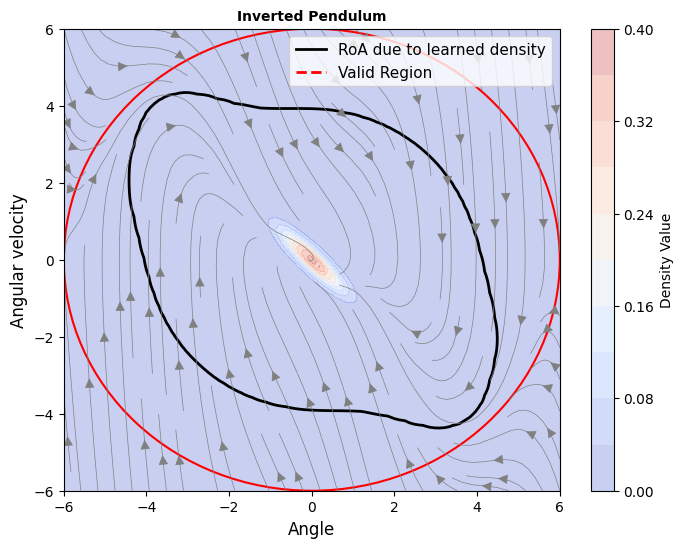

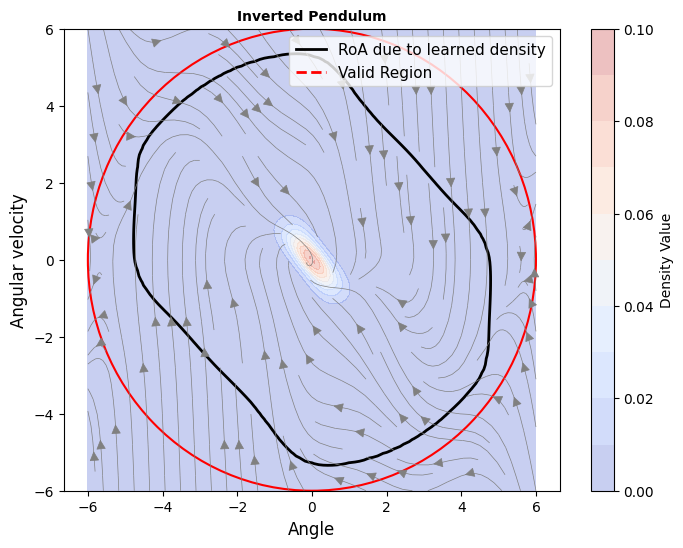

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'Inverted Pendulum'}, xlabel='Angle', ylabel='Angular velocity'>)

In [13]:

# Call the function to plot density contours and flow field
plot_density_countours(a_net, b_net, c_net,1e-14, device, plot_flow=True)


# Call the function to plot density contours and flow field
plot_density_countours(a_net1, b_net1, c_net1,1e-14, device, plot_flow=True)


/tmp/ipykernel_767034/4002352940.py:20: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X,Y,rho_set-density_threshold,levels=0,colors='black', linewidths=2,linestyles='solid', label='Mixed Density')


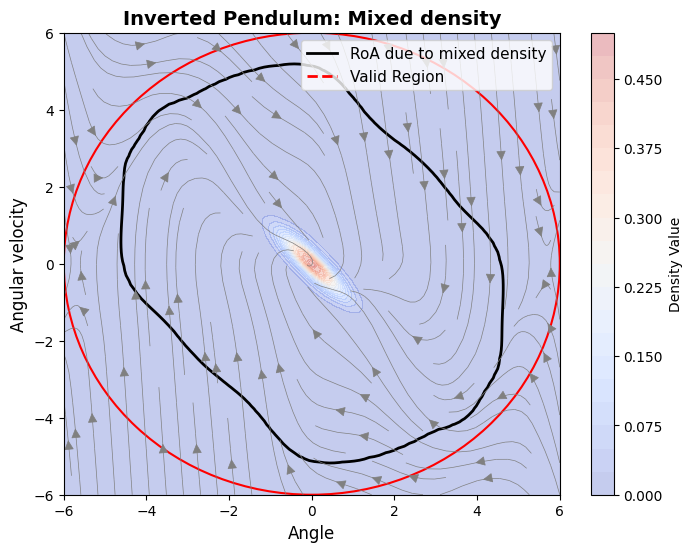

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'Inverted Pendulum: Mixed density'}, xlabel='Angle', ylabel='Angular velocity'>)

In [16]:
def plot_mixed_density_countours(a_nn, b_nn, c_nn,a_nn1,b_nn1,c_nn1, density_threshold, device, plot_flow=True):
    # create meshgrid
    x1 = torch.linspace(-6, 6, 100)
    x2 = torch.linspace(-6, 6, 100)
    X, Y = np.meshgrid(x1,x2)

    # Convert to torch tensor
    grid_points = torch.tensor(np.column_stack([X.ravel(), Y.ravel()]), dtype=torch.float32).to(device)

    # compute the modified density function
    with torch.no_grad():
        rho_set1 = a_nn(grid_points) / (torch.exp( torch.sum(grid_points**2, dim=1, keepdim=True) + torch.sum((b_nn(grid_points))**2, dim=1, keepdim=True)))
        rho_set2 = a_nn1(grid_points) / (torch.exp( torch.sum(grid_points**2, dim=1, keepdim=True) + torch.sum((b_nn1(grid_points))**2, dim=1, keepdim=True)))
        rho_set =  rho_set1+rho_set2
        rho_set = rho_set.squeeze()
        rho_set = rho_set.cpu().numpy().reshape(X.shape)
    # plot the density function
    fig, ax = plt.subplots(figsize=(8, 6))
    
    ax.contour(X,Y,rho_set-density_threshold,levels=0,colors='black', linewidths=2,linestyles='solid', label='Mixed Density')
    filled_contours = ax.contourf(X, Y, rho_set, levels=20, alpha=0.3, cmap=cm.coolwarm)
    plt.colorbar(filled_contours, label='Density Value')

    if plot_flow:
        # create coarser grid for flow field
        x1_flow = np.linspace(-6, 6, 20)
        x2_flow = np.linspace(-6, 6, 20)
        X_flow, Y_flow = np.meshgrid(x1_flow, x2_flow)
        flow_points = torch.tensor(np.column_stack([X_flow.ravel(), Y_flow.ravel()]), dtype=torch.float32).to(device)

        # evaluate control policy u
        with torch.no_grad():
            rho_set1 = a_nn(flow_points) / (torch.exp( torch.sum(flow_points**2, dim=1, keepdim=True) + torch.sum((b_nn(flow_points))**2, dim=1, keepdim=True)))
            rho_set2 = a_nn1(flow_points) / (torch.exp( torch.sum(flow_points**2, dim=1, keepdim=True) + torch.sum((b_nn1(flow_points))**2, dim=1, keepdim=True)))
            u_values1 = c_nn(flow_points) / a_nn(flow_points)
            u_values2 = c_nn1(flow_points) / a_nn1(flow_points)
            weight1 = rho_set1 / (rho_set1+rho_set2)
            weight2 = rho_set2 / (rho_set1+rho_set2)
            u_values = weight1 * u_values1 + weight2 * u_values2
               
        # Calculate vector field
        DX = np.zeros_like(X_flow)
        DY = np.zeros_like(Y_flow)
        
        for i in range(len(x1_flow)):
            for j in range(len(x2_flow)):
                idx = i * len(x1_flow) + j
                x = torch.tensor([X_flow[i, j], Y_flow[i, j]], device=device)
                f_val = f(x)
                g_val = g(x)
                u = u_values[idx]
                
                # Compute flow: f(x) + g(x)u
                flow = f_val + g_val * u
                DX[i, j] = flow[0].cpu().numpy()
                DY[i, j] = flow[1].cpu().numpy()
        
        # Normalize vectors for better visualization
        magnitude = np.sqrt(DX**2 + DY**2)
        DX = DX / magnitude
        DY = DY / magnitude
        
        # Plot flow field
        ax.streamplot(X_flow, Y_flow, DX, DY, color='gray', linewidth=0.5,
                     density=1.0, arrowstyle='-|>', arrowsize=1.5)
    
    # Add valid region circle
    circle = plt.Circle((0, 0), 6, color='r', fill=False, linewidth=1.5, label='Valid Region')
    ax.add_artist(circle)
    
    # Customize plot
    ax.set_xlabel('Angle', fontsize=12)
    ax.set_ylabel('Angular velocity', fontsize=12)
    ax.set_title('Inverted Pendulum: Mixed density', fontsize=14, fontweight='bold')
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='black', linewidth=2, linestyle='-', label='RoA due to mixed density'),
        Line2D([0], [0], color='red', linewidth=2, linestyle='--', label='Valid Region')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=11)
    
    
   
    
    plt.show()
    
    return fig, ax


# Call the function to plot density contours and flow field
plot_mixed_density_countours(a_net, b_net, c_net,a_net1,b_net1,c_net1, 5e-14, device, plot_flow=True)



# Yang et al

comparaison with yang et al

In [17]:
import math
import typing
from typing import Optional, Union

In [18]:

class NeuralNetworkLyapunov(nn.Module):
    """
    V(x) = V_nominal(x) + network_output(x) + V_psd_output(x)
    V_nominal(x) contains NO optimizable parameters.
    network_output =
    ϕ(x) − ϕ(x*) if absolute_output = False
    |ϕ(x) − ϕ(x*)| if absolute_output = True
    V_psd_output =
    |(εI+RᵀR)(x-x*)|₁ if V_psd_form = "L1"
    (x-x*)ᵀ(εI+RᵀR)(x-x*) if V_psd_form = "quadratic".
    |R(x-x*)|₁ if V_psd_form = "L1_R_free"

    The optimizable parameters are the network ϕ and R.
    """

    def __init__(
        self,
        goal_state: torch.Tensor,
        hidden_widths: list,
        x_dim: int,
        R_rows: int,
        absolute_output: bool,
        eps: float,
        activation: nn.Module,
        nominal: typing.Optional[typing.Callable[[torch.Tensor], torch.Tensor]] = None,
        V_psd_form: str = "L1",
        *args,
        **kwargs
    ):
        """
        Args:
          hidden_widths: hidden_widths[i] is the width of the i'th hidden
          layer. This doesn't include the output layer, which always have
          width 1.
          x_dim: The dimension of state
          R_rows: The number of rows in matrix R.
          absolute_output: If absolute_output=False,
          then V(x) = V_nominal(x) + ϕ(x) − ϕ(x*) + |(εI+RᵀR)(x-x*)|₁
          otherwise V(x) = V_nominal(x) + |ϕ(x) − ϕ(x*)| + |(εI+RᵀR)(x-x*)|₁
          nominal: V_nominal(x) in the documentation above. If nominal=None,
          then we ignore V_nominal(x). Note that V_nominal(x*) should be 0.
          nominal(x) should support batch computation.
        """
        super().__init__(*args, **kwargs)
        self.goal_state = goal_state
        self.x_dim = x_dim
        assert self.goal_state.shape == (self.x_dim,)
        if hidden_widths is None:
            layers = []
        else:
            layers = [
                nn.Linear(
                    in_features=self.x_dim,
                    out_features=1 if len(hidden_widths) == 0 else hidden_widths[0],
                )
            ]
            for layer, width in enumerate(hidden_widths):
                layers.append(activation())
                layers.append(
                    nn.Linear(
                        in_features=width,
                        out_features=hidden_widths[layer + 1]
                        if layer != len(hidden_widths) - 1
                        else 1,
                    )
                )
            for l in layers:
                if isinstance(l, nn.Linear):
                    torch.nn.init.kaiming_uniform_(l.weight, nonlinearity="relu")
                    # print(f'layer max={l.weight.max().item()}, min={l.weight.min().item()}')
                    # l.weight.data.clamp_(min=-0.5, max=0.5)
        self.net = nn.Sequential(*layers)
        self.layers = layers
        assert isinstance(absolute_output, bool)
        self.absolute_output = absolute_output
        assert isinstance(eps, float)
        self.R_rows = R_rows
        # If R_rows is set to 0 we will not use R.
        if R_rows > 0:
            # assert (eps > 0)
            self.eps = eps
            # Rt is the transpose of R
            self.register_parameter(
                name="R",
                param=torch.nn.Parameter(torch.rand((R_rows, self.x_dim)) - 0.5),
            )
        self.nominal = nominal
        if self.nominal is not None:
            assert self.nominal(self.goal_state.unsqueeze(0))[0].item() == 0
        self.V_psd_form = V_psd_form

    def _network_output(self, x: torch.Tensor) -> torch.Tensor:
        if len(self.net) > 0:
            phi = self.net(x)
            phi_star = self.net(self.goal_state)
            return phi - phi_star
        else:
            return torch.zeros((x.shape[0], 1), device=x.device, dtype=x.dtype)

    def _V_psd_output(self, x: torch.Tensor):
        """
        Compute
        |(εI+RᵀR)(x-x*)|₁
        or
        (x-x*)ᵀ(εI+RᵀR)(x-x*)
        or
        |R(x-x*)|₁
        """
        if self.R_rows > 0:
            eps_plus_RtR = self.eps * torch.eye(self.x_dim, device=x.device) + (
                self.R.transpose(0, 1) @ self.R
            )
            if self.V_psd_form == "L1":
                Rx = (x - self.goal_state) @ eps_plus_RtR
                # Use relu(x) + relu(-x) instead of torch.abs(x) since the verification code does relu splitting.
                l1_term = (
                    torch.nn.functional.relu(Rx) + torch.nn.functional.relu(-Rx)
                ).sum(dim=-1, keepdim=True)
                return l1_term
            elif self.V_psd_form == "quadratic":
                return torch.sum(
                    (x - self.goal_state) * ((x - self.goal_state) @ eps_plus_RtR),
                    dim=-1,
                    keepdim=True,
                )
            elif self.V_psd_form == "L1_R_free":
                Rx = (x - self.goal_state) @ self.R.transpose(0, 1)
                # Use relu(x) + relu(-x) instead of torch.abs(x) since the verification code does relu splitting.
                l1_term = (
                    torch.nn.functional.relu(Rx) + torch.nn.functional.relu(-Rx)
                ).sum(dim=-1, keepdim=True)
                return l1_term
            else:
                raise NotImplementedError
        else:
            return torch.zeros((x.shape[0], 1), dtype=x.dtype, device=x.device)

    def forward(self, x):
        V_nominal = 0 if self.nominal is None else self.nominal(x)

        network_output = self._network_output(x)
        V_psd_output = self._V_psd_output(x)
        if self.absolute_output:
            return (
                V_nominal
                + torch.nn.functional.relu(network_output)
                + torch.nn.functional.relu(-network_output)
                + V_psd_output
            )
        else:
            return V_nominal + network_output + V_psd_output

    def _apply(self, fn):
        """Handles CPU/GPU transfer and type conversion."""
        super()._apply(fn)
        self.goal_state = fn(self.goal_state)
        return self


In [19]:
CKPT_PATH = "Models/lyapunov_nn_pendulum.pth"
 

In [20]:

# ── 2. architecture — must match cfg.model.lyapunov.* from training ──────────
HIDDEN_WIDTHS = [16, 16, 8]   
V_PSD_FORM    = "L1"           
R_ROWS        = 3              
 

In [21]:
# ── 3. build & load ───────────────────────────────────────────────────────────
lyapunov_nn = NeuralNetworkLyapunov(          # class already defined above
    goal_state    = torch.tensor([0.0, 0.0]), # pendulum equilibrium
    hidden_widths = HIDDEN_WIDTHS,
    x_dim         = 2,
    R_rows        = R_ROWS,
    absolute_output = True,                   # matches training script
    eps           = 0.01,
    activation    = nn.LeakyReLU,
    V_psd_form    = V_PSD_FORM,
).to(device)
 

In [22]:

ckpt = torch.load(CKPT_PATH, map_location=device)
lyapunov_nn.load_state_dict(ckpt["state_dict"])
lyapunov_nn.eval()
 

/tmp/ipykernel_767034/112691856.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(CKPT_PATH, map_location=device)


NeuralNetworkLyapunov(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=16, out_features=8, bias=True)
    (5): LeakyReLU(negative_slope=0.01)
    (6): Linear(in_features=8, out_features=1, bias=True)
  )
)

In [23]:

tau_yang2024 = ckpt["rho"].item() if isinstance(ckpt["rho"], torch.Tensor) else float(ckpt["rho"])
print(f"Loaded lyapunov_nn  |  tau_yang2024 = {tau_yang2024:.6f}")

Loaded lyapunov_nn  |  tau_yang2024 = 0.078518


In [24]:

def lyapunov_yang(x):
    """
    Drop-in replacement for the hardcoded lyapunov().
    x : torch.Tensor  shape [N, 2]
    returns : torch.Tensor  shape [N]   (same as the original function)
    """
    with torch.no_grad():
        return lyapunov_nn(x).squeeze(1)   # [N, 1] → [N]


In [33]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.patches import Circle


def plot_combined_roa_yang(a_nn, b_nn, c_nn, a_nn1, b_nn1, c_nn1, 
                      device, alpha=0.005, 
                      density_threshold=0.55, 
                      lyapunov_threshold=0.27,
                      lyapunov_yang_threshold=0.12,
                      plot_flow=True):
    """
    Plot both ROAs on the same plot for direct comparison
    """
    
    # Create meshgrid
    x1 = torch.linspace(-6, 6, 200)
    x2 = torch.linspace(-6, 6, 200)
    X, Y = np.meshgrid(x1, x2)

    grid_points = torch.tensor(np.column_stack([X.ravel(), Y.ravel()]),
                               dtype=torch.float32).to(device)

    with torch.no_grad():
        # Compute densities
        rho1 = 10 * a_nn(grid_points) / (
            torch.exp(torch.sum(grid_points**2, dim=1, keepdim=True)
                     + torch.sum((b_nn(grid_points))**2, dim=1, keepdim=True)))
        rho2 = 10 * a_nn1(grid_points) / (
            torch.exp(torch.sum(grid_points**2, dim=1, keepdim=True)
                     + torch.sum((b_nn1(grid_points))**2, dim=1, keepdim=True)))
        
    
        mixed_rho = ( rho1 + rho2 ) / 10 
        mixed_rho = mixed_rho.squeeze().cpu().numpy().reshape(X.shape)
        rho1 = rho1.squeeze().cpu().numpy().reshape(X.shape)
        rho2 = rho2.squeeze().cpu().numpy().reshape(X.shape)
        

        lyap_yang_vals = lyapunov_yang(grid_points).cpu().numpy().reshape(X.shape)

    # Create single plot
    fig, ax = plt.subplots(figsize=(8, 6))

    # Plot density contours
    filled_contours = ax.contourf(X, Y, mixed_rho, alpha=0.3, 
                                  cmap=cm.coolwarm)
    plt.colorbar(filled_contours, ax=ax, label='Combined Density Value')


    mixed_density_contour = ax.contour(X, Y, mixed_rho - density_threshold, levels=0,
                                       colors='blue', linewidths=2, 
                                       linestyles='solid', label='Learned Density ROA')
    

    contour_lyap_yang = ax.contour(X, Y, lyap_yang_vals, levels=[lyapunov_yang_threshold], colors='black', linewidths=2, linestyles='solid', label='Lyapunov Yang ROA')

    if plot_flow:
        # Flow field
        x1_flow = np.linspace(-6, 6, 20)
        x2_flow = np.linspace(-6, 6, 20)
        X_flow, Y_flow = np.meshgrid(x1_flow, x2_flow)
        flow_points = torch.tensor(np.column_stack([X_flow.ravel(), Y_flow.ravel()]),
                                dtype=torch.float32).to(device)

        with torch.no_grad():
            rho1_flow = 10 * a_nn(flow_points) / (
                torch.exp(torch.sum(flow_points**2, dim=1, keepdim=True)
                        + torch.sum((b_nn(flow_points))**2, dim=1, keepdim=True)))
            rho2_flow = 10 * a_nn1(flow_points) / (
                torch.exp(torch.sum(flow_points**2, dim=1, keepdim=True)
                        + torch.sum((b_nn1(flow_points))**2, dim=1, keepdim=True)))
            
            rho_total_flow = rho1_flow + rho2_flow 
            w1, w2 = rho1_flow / rho_total_flow, rho2_flow / rho_total_flow

            u1 = c_nn(flow_points) / a_nn(flow_points)
            u2 = c_nn1(flow_points) / a_nn1(flow_points)
            u_values = w1 * u1 + w2 * u2

        DX, DY = np.zeros_like(X_flow), np.zeros_like(Y_flow)
        for i in range(len(x1_flow)):
            for j in range(len(x2_flow)):
                idx = i * len(x1_flow) + j
                x = torch.tensor([X_flow[i, j], Y_flow[i, j]], device=device)
                f_val = f(x)
                g_val = g(x)
                u = u_values[idx]
                flow = f_val + g_val * u
                DX[i, j], DY[i, j] = flow[0].cpu().numpy(), flow[1].cpu().numpy()

        magnitude = np.sqrt(DX**2 + DY**2)
        DX, DY = DX / (magnitude + 1e-8), DY / (magnitude + 1e-8)

        ax.streamplot(X_flow, Y_flow, DX, DY, color='gray',
                     linewidth=0.5, density=1.0,
                     arrowstyle='-|>', arrowsize=1.5)



    ax.set_xlabel('Angle')
    ax.set_ylabel('Anglular velocity')
    ax.set_title('Inverted Pendulum')
    circle = plt.Circle((0, 0), 6, color='r', fill=False,
                        linewidth=1.5, label='Valid Region')
    ax.add_artist(circle)
    # Create custom legend
    from matplotlib.lines import Line2D

    legend_elements = [
        Line2D([0], [0], color='blue', linewidth=2, linestyle='-', label='Mixed Density Controller '),
        Line2D([0], [0], color='black', linewidth=2, linestyle='-', label='Lyapunov (Yang et al 2024) Controller'),
        Line2D([0], [0], color='red', linewidth=2, linestyle='-', label='Valid Region')

    ]
    # ax.legend(handles=legend_elements, loc='upper right', fontsize=11)
    ax.legend(
    handles=legend_elements,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.12),   # x=centre, y=below the axes
    ncol=2,                         # both entries side by side
    fontsize=11,
    frameon=True,
    )

    plt.tight_layout()
    plt.show()

    return fig, ax



/tmp/ipykernel_767034/307668454.py:53: UserWarning: The following kwargs were not used by contour: 'label'
  mixed_density_contour = ax.contour(X, Y, mixed_rho - density_threshold, levels=0,
/tmp/ipykernel_767034/307668454.py:58: UserWarning: The following kwargs were not used by contour: 'label'
  contour_lyap_yang = ax.contour(X, Y, lyap_yang_vals, levels=[lyapunov_yang_threshold], colors='black', linewidths=2, linestyles='solid', label='Lyapunov Yang ROA')


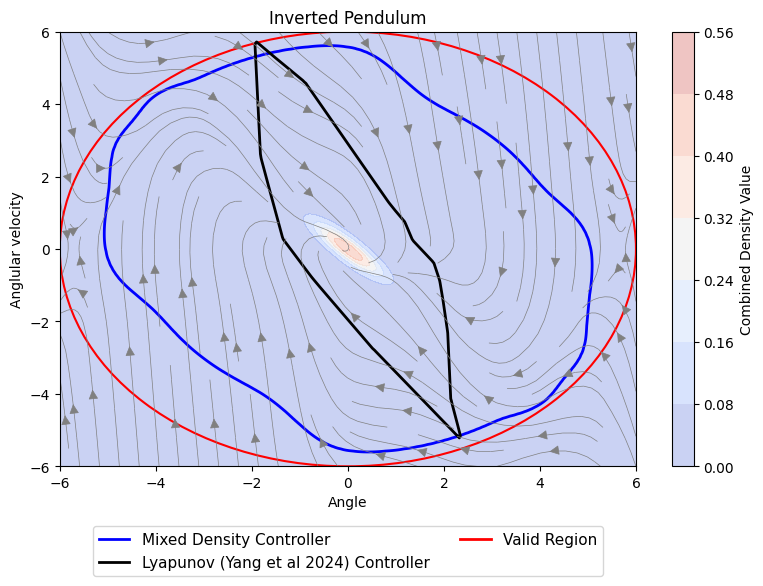

In [34]:


# 2. Combined plot (similar to your reference image)
fig, ax = plot_combined_roa_yang(a_net, b_net, c_net, a_net1, b_net1, c_net1, 
                           device, alpha=0.005, 
                           density_threshold=5e-16, 
                           lyapunov_threshold=0.11,
                           lyapunov_yang_threshold=tau_yang2024*0.96)